# MP2 Parts 2–4 (jtyuill)
Aggregation, visualization, gap analysis and interpretation for the 10 assigned projects.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

NETID = "jtyuill"
projects = list(pd.read_csv("net2prj.csv").query("netID == @NETID")["WoC"])
df = pd.read_csv(f"{NETID}_project_summary.csv", sep=";")
df.columns = ["project", "commit", "author", "time", "message"]
df["Month"] = pd.to_datetime(df["time"], unit="s").dt.to_period("M")
df.groupby("project").size()

project
choderalab_pymbar                  1492
clue-developers_clue                842
ifcopenshell_ifcopenshell         25237
jakobrunge_tigramite               1379
johannfaouzi_pyts                   791
kvos_coastsat                       642
lastools_lastools                  2712
opendatacube_datacube-explorer     6011
tensorflow_tfjs                   31325
zalo_cascadestudio                  361
dtype: int64

## Part 2: monthly time series and plots

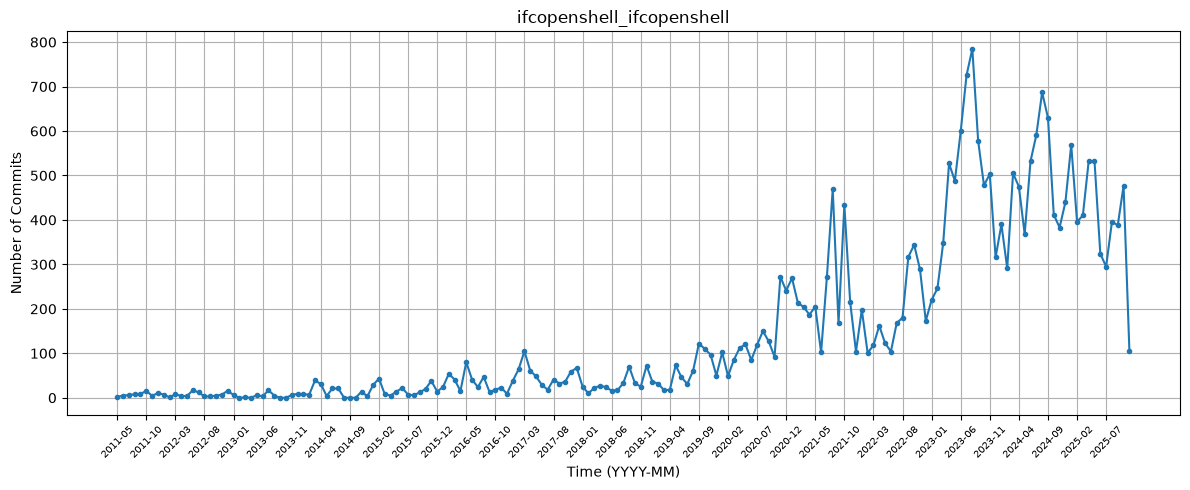

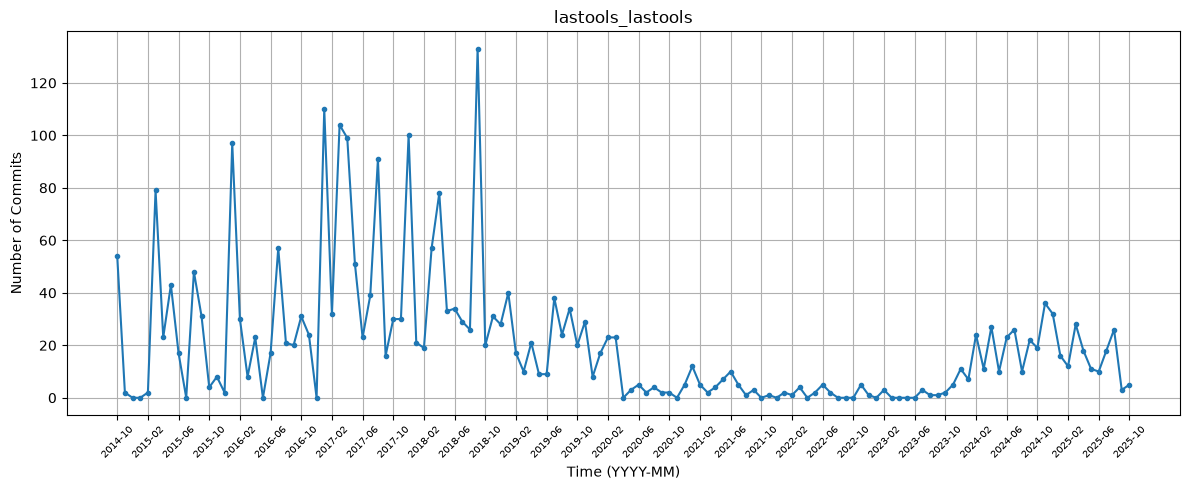

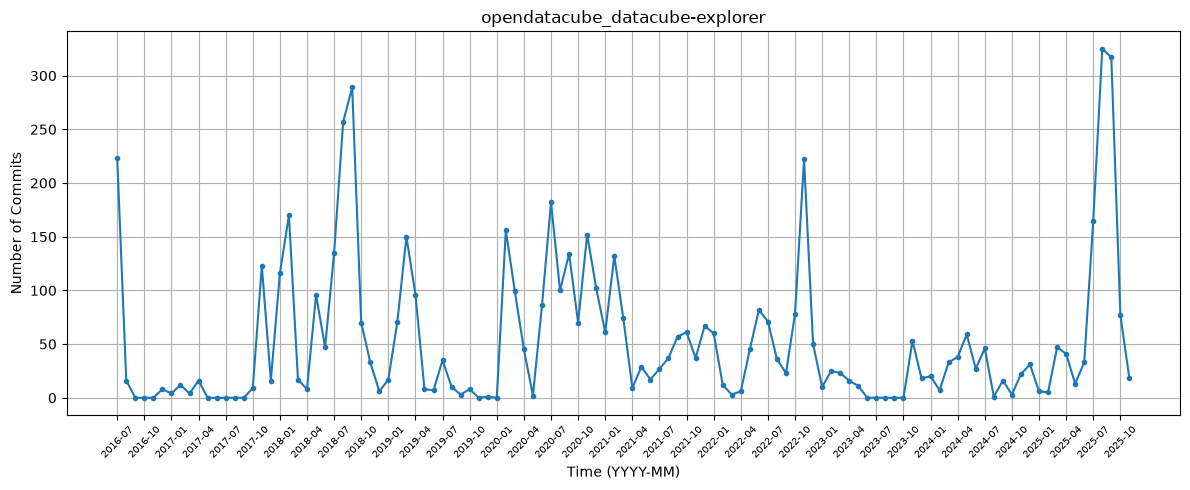

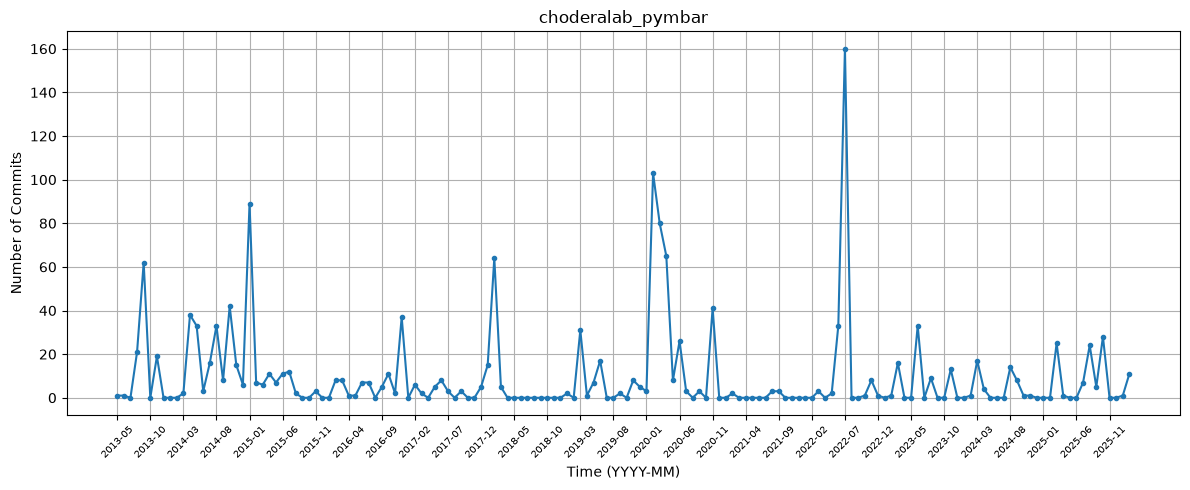

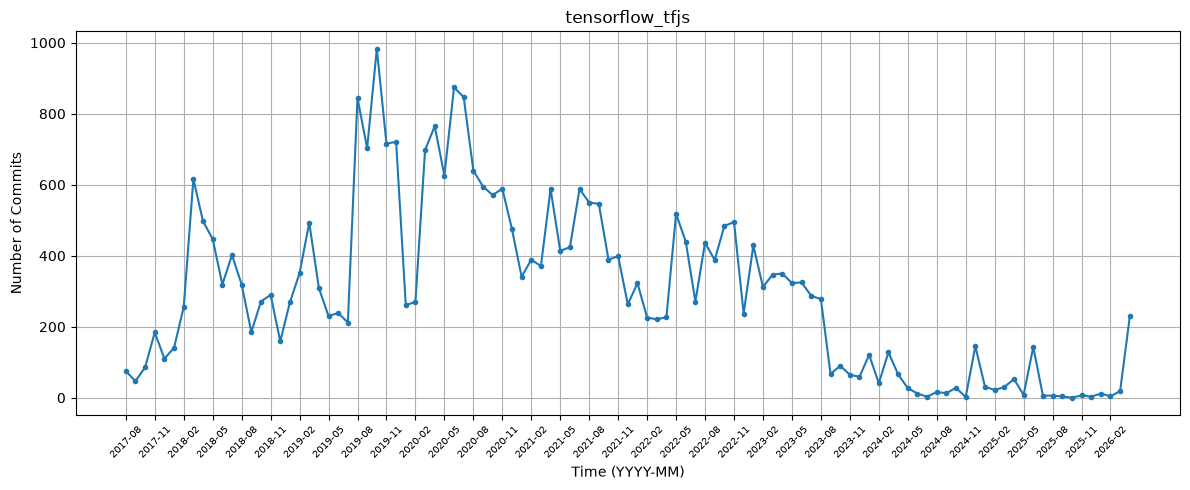

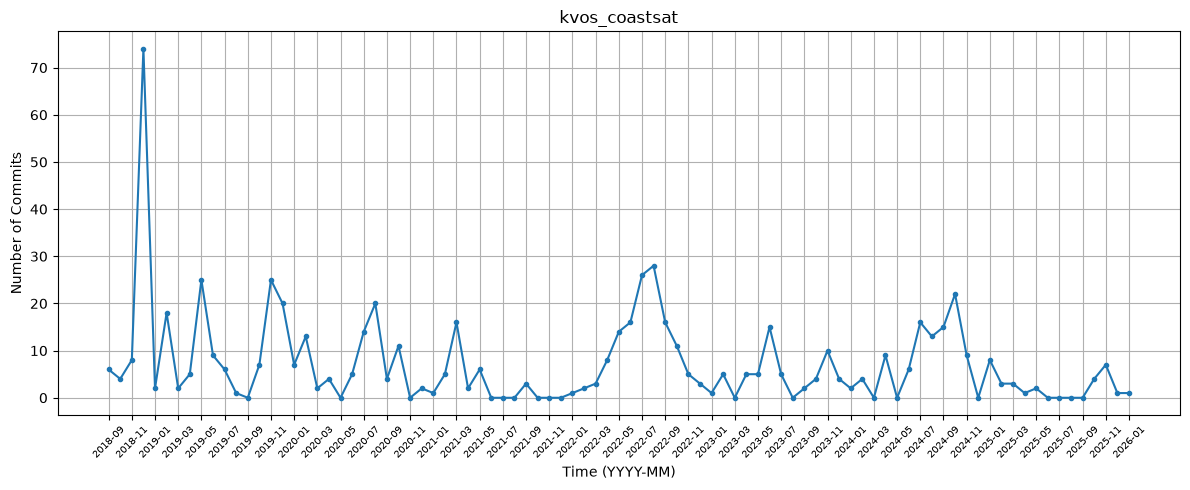

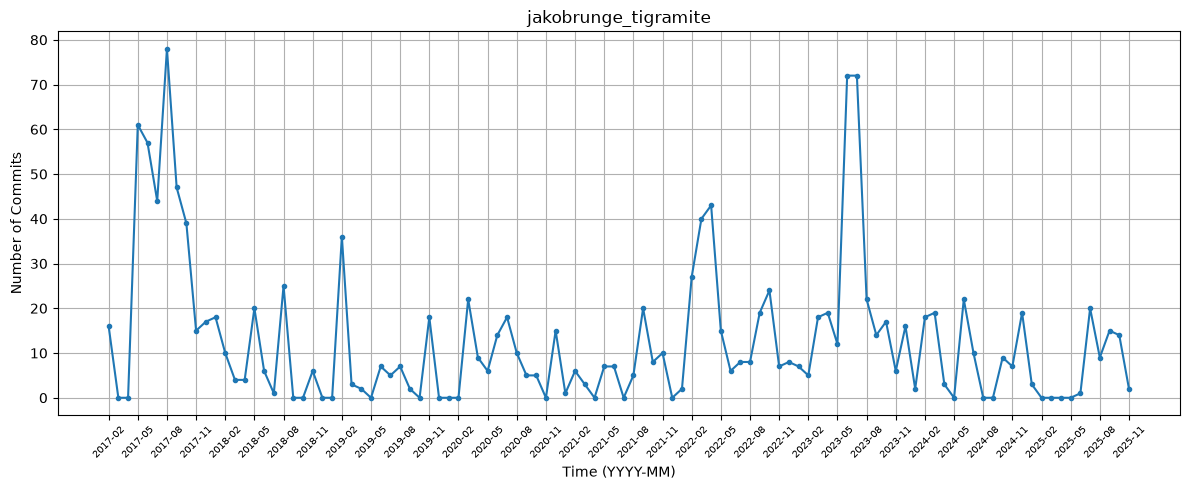

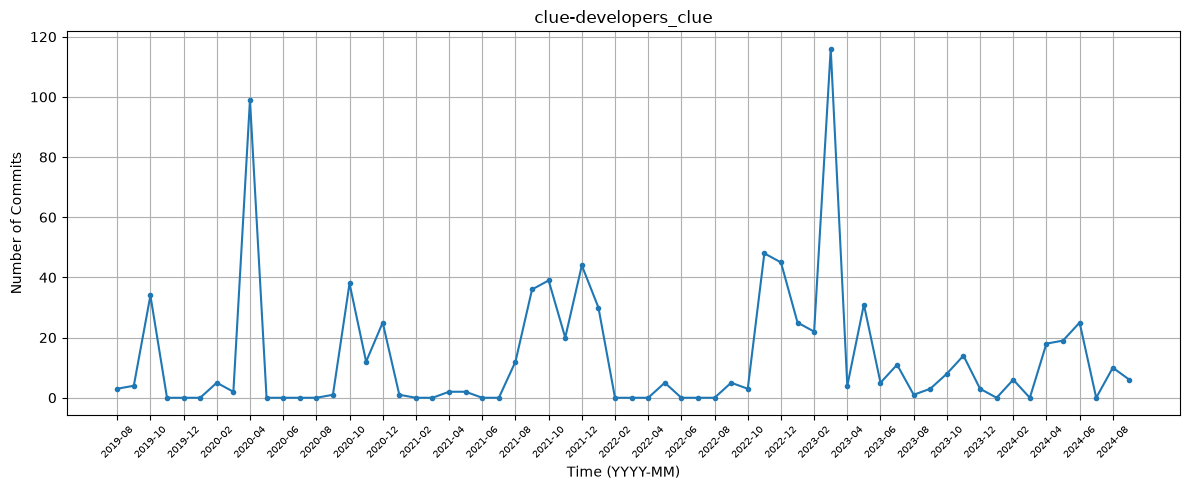

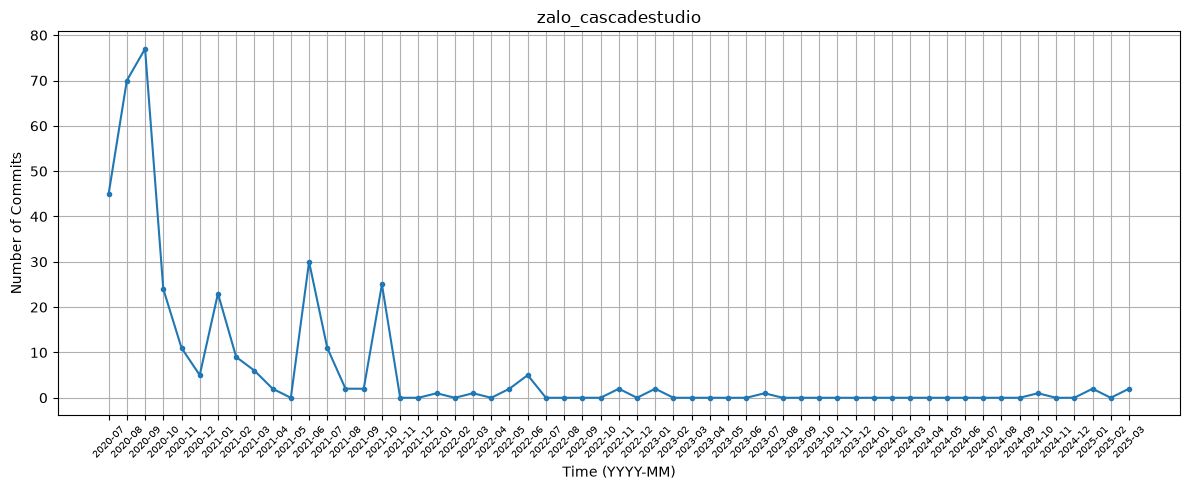

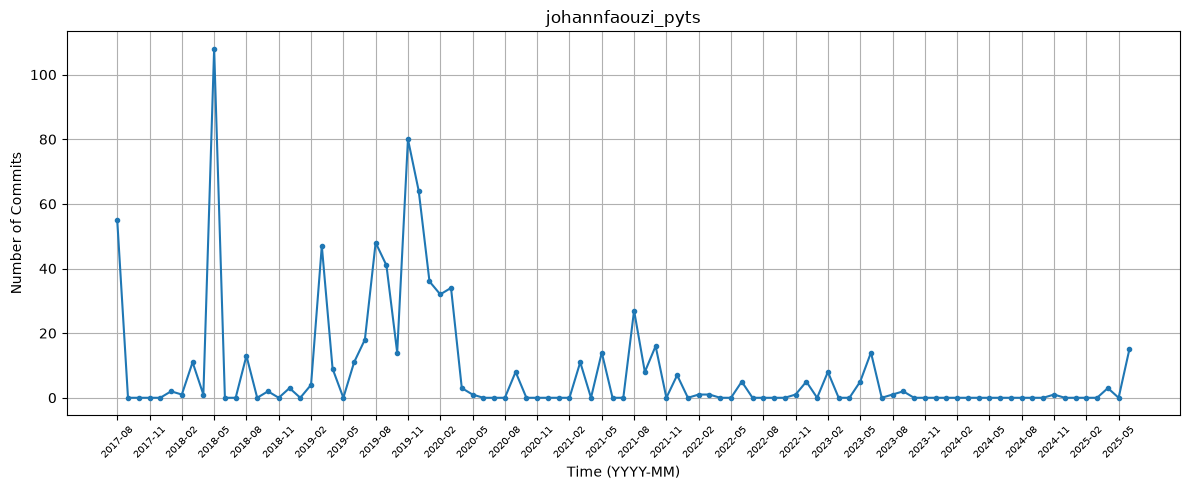

{'ifcopenshell_ifcopenshell': 175,
 'lastools_lastools': 133,
 'opendatacube_datacube-explorer': 113,
 'choderalab_pymbar': 154,
 'tensorflow_tfjs': 105,
 'kvos_coastsat': 89,
 'jakobrunge_tigramite': 106,
 'clue-developers_clue': 62,
 'zalo_cascadestudio': 57,
 'johannfaouzi_pyts': 95}

In [2]:
def monthly(prj):
    counts = df[df["project"] == prj].groupby("Month").size()
    months = pd.period_range(counts.index.min(), counts.index.max(), freq="M")
    return counts.reindex(months, fill_value=0)

series = {}
for prj in projects:
    s = monthly(prj)
    series[prj] = s
    ts = pd.DataFrame({"Month": s.index.strftime("%Y-%m"), "#Commits": s.values})
    ts.to_csv(f"{NETID}_commits_timeseries_{prj}.csv", sep=";", index=False)

    plt.figure(figsize=(12, 5))
    plt.plot(ts["Month"], ts["#Commits"], marker="o", markersize=3, linestyle="-")
    plt.xlabel("Time (YYYY-MM)")
    plt.ylabel("Number of Commits")
    plt.title(prj)
    plt.grid(True)
    step = max(1, len(ts) // 30)
    plt.xticks(range(0, len(ts), step), ts["Month"][::step], rotation=45, fontsize=7)
    plt.tight_layout()
    plt.savefig(f"{NETID}_timeseries_{prj}.png", dpi=300)
    plt.show()
{p: len(s) for p, s in series.items()}

### Longest inactivity gap
A gap is a run of consecutive zero-commit months inside the project's first..last commit month. Start/End are the first/last zero month (inclusive). On ties the earliest run is used. `NumberOfGapsInTimeline` counts runs of at least 3 zero months.

In [3]:
def zero_runs(s):
    runs, start = [], None
    for i, v in enumerate(s.values):
        if v == 0 and start is None:
            start = i
        elif v != 0 and start is not None:
            runs.append((start, i - 1))
            start = None
    return runs  # series ends on a non-zero month, so no open run remains

# Values gathered from GitHub in Part 1 (jtyuill.ipynb)
github = {
    "ifcopenshell_ifcopenshell": (2808, 973, "2026-09-28"),
    "lastools_lastools": (1070, 405, "2026-09-21"),
    "opendatacube_datacube-explorer": (64, 35, "2026-09-25"),
    "choderalab_pymbar": (318, 101, "2026-02-12"),
    "tensorflow_tfjs": (19146, 2029, "2026-04-06"),
    "kvos_coastsat": (898, 309, "2026-05-29"),
    "jakobrunge_tigramite": (1726, 323, "2026-01-14"),
    "clue-developers_clue": (14, 11, "2024-09-12"),
    "zalo_cascadestudio": (1484, 181, "2026-06-16"),
    "johannfaouzi_pyts": (1880, 179, "2025-06-18"),
}

rows, gaps = [], {}
for prj in projects:
    d, s = df[df["project"] == prj], series[prj]
    runs = zero_runs(s)
    a, b = max(runs, key=lambda r: r[1] - r[0]) if runs else (None, None)
    gaps[prj] = (s.index[a], s.index[b]) if runs else None
    stars, forks, last = github[prj]
    rows.append({
        "Project": prj,
        "ncommits": len(d),
        "nauthors": d["author"].nunique(),
        "from": d["time"].min(),
        "to": d["time"].max(),
        "nstars": stars,
        "nforks": forks,
        "lastGHCommitDate": last,
        "LongestGapStart": str(s.index[a]) if runs else "N/A",
        "LongestGapEnd": str(s.index[b]) if runs else "N/A",
        "LongestGapLength": b - a + 1 if runs else 0,
        "NumCommitsAfterLastGap": int((d["Month"] > s.index[b]).sum()) if runs else len(d),
        "NumberOfGapsInTimeline": sum(e - st + 1 >= 3 for st, e in runs),
    })
stats = pd.DataFrame(rows)
stats

,Project,ncommits,nauthors,from,to,nstars,nforks,lastGHCommitDate,LongestGapStart,LongestGapEnd,LongestGapLength,NumCommitsAfterLastGap,NumberOfGapsInTimeline
0,ifcopenshell_ifcopenshell,25237,428,1304852672,1762623536,2808,973,2026-09-28,2014-08,2014-10,3,24906,1
1,lastools_lastools,2712,87,1413703399,1761411541,1070,405,2026-09-21,2023-03,2023-06,4,417,2
2,opendatacube_datacube-explorer,6011,53,1468452526,1762320537,64,35,2026-09-25,2017-05,2017-09,5,5728,3
3,choderalab_pymbar,1492,61,1368225944,1771982683,318,101,2026-02-12,2018-04,2018-12,9,841,6
4,tensorflow_tfjs,31325,705,1501782313,1776389827,19146,2029,2026-04-06,2025-10,2025-10,1,274,0
5,kvos_coastsat,642,30,1538116640,1768665837,898,309,2026-05-29,2025-06,2025-09,4,13,3
6,jakobrunge_tigramite,1379,56,1486320043,1762336405,1726,323,2026-01-14,2025-02,2025-05,4,61,2
7,clue-developers_clue,842,17,1567025867,1726151591,14,11,2024-09-12,2020-05,2020-08,4,695,4
8,zalo_cascadestudio,361,14,1595495597,1741942474,1484,181,2026-06-16,2023-08,2024-09,14,5,3
9,johannfaouzi_pyts,791,30,1501756392,1750449970,1880,179,2025-06-18,2023-10,2024-10,13,19,6


## Part 3.1: commits before and after the longest gap

In [4]:
parts = []
for prj in projects:
    d = df[df["project"] == prj].sort_values("time")
    gs, ge = gaps[prj]
    pre = d[d["Month"] < gs].tail(10).assign(**{"pre/post": "pre"})
    post = d[d["Month"] > ge].head(10).assign(**{"pre/post": "post"})
    parts += [pre, post]
gap_commits = pd.concat(parts)[["pre/post", "project", "commit", "author", "time", "message"]]
gap_commits.columns = ["pre/post", "project_wocid", "commit_sha1", "author", "time", "commit message"]
gap_commits.to_csv(f"{NETID}_project_gap_commits.csv", sep=";", index=False)
gap_commits.groupby(["project_wocid", "pre/post"]).size()

project_wocid                   pre/post
choderalab_pymbar               post        10
                                pre         10
clue-developers_clue            post        10
                                pre         10
ifcopenshell_ifcopenshell       post        10
                                pre         10
jakobrunge_tigramite            post        10
                                pre         10
johannfaouzi_pyts               post        10
                                pre         10
kvos_coastsat                   post        10
                                pre         10
lastools_lastools               post        10
                                pre         10
opendatacube_datacube-explorer  post        10
                                pre         10
tensorflow_tfjs                 post        10
                                pre         10
zalo_cascadestudio              post         5
                                pre         10
dtype: int64

## Part 2/3/4 judgments
Activity pattern, themes and gap reasons were filled in by hand after looking at the plots, the commits before and after each gap, and the GitHub repo. More detail is in the reflection files.

In [5]:
judgments = {'ifcopenshell_ifcopenshell': {'ActivityPattern': 'rising',
                               'BeforeThemes': 'Bug fixes:Feature development',
                               'AfterThemes': 'Bug fixes:Feature development',
                               'HypothesizedGapReason': 'Probably the main maintainer (Thomas Krijnen) was busy or '
                                                        'away for a few months. No commit messages or README changes '
                                                        'mention a pause.',
                               'HasRecovered': 'Yes',
                               'WhyRecovered': 'Krijnen came back in November 2014 and kept working on parser and '
                                               'geometry fixes.',
                               'WhoRecovered': 'Same person, Thomas Krijnen. New contributors joined later.',
                               'Currentstatus': 'Active',
                               'RecentThemes': 'Dependency updates:Release',
                               'Notes': 'IfcOpenShell has grown a lot over time, peaking at 785 commits in 2023-08. '
                                        'Its only 3+ month gap was in 2014, before the project moved to GitHub, so it '
                                        'was hard to explain. The same maintainer ended it and the project is still '
                                        'active.'},
 'lastools_lastools': {'ActivityPattern': 'U-shaped',
                       'BeforeThemes': 'Feature development:Bug fixes',
                       'AfterThemes': 'Bug fixes:Feature development',
                       'HypothesizedGapReason': 'The founder Martin Isenburg died in 2021, leaving a small team to '
                                                'maintain it. Issues opened during the gap got no replies.',
                       'HasRecovered': 'Yes',
                       'WhyRecovered': 'Jean-Romain added a COPC reader/writer and Jochen Keil went back to fixing '
                                       'bugs.',
                       'WhoRecovered': 'Same people (Jean-Romain and Jochen Keil). New contributors joined in 2024.',
                       'Currentstatus': 'Active',
                       'RecentThemes': 'Release:Documentation updates',
                       'Notes': 'LAStools is U-shaped: very active until 2019, low from 2020 to 2023, then active '
                                'again in 2024. The longest gap (2023-03 to 2023-06) is in the low period after the '
                                'founder died. The same contributors brought it back and it is Active.'},
 'opendatacube_datacube-explorer': {'ActivityPattern': 'irregular',
                                    'BeforeThemes': 'Feature development:Documentation updates',
                                    'AfterThemes': 'Bug fixes:Feature development',
                                    'HypothesizedGapReason': 'In 2017 almost all commits came from one developer '
                                                             '(Jeremy Hooke), and work stopped after his April 2017 '
                                                             'commits.',
                                    'HasRecovered': 'Yes',
                                    'WhyRecovered': 'A Geoscience Australia user reported and fixed a deployment bug, '
                                                    'then Hooke went back to adding features.',
                                    'WhoRecovered': 'Mix: new contributor Alex Vincent and the original maintainer '
                                                    'Jeremy Hooke.',
                                    'Currentstatus': 'Active',
                                    'RecentThemes': 'Dependency updates:Automated bot contributions',
                                    'Notes': 'Irregular activity with big bursts and 3 gaps of 3+ months. Two 5-month '
                                             'gaps tie, so I used the earlier one (2017-05 to 2017-09). It came back '
                                             'when a new contributor from Geoscience Australia started sending fixes. '
                                             'Active, recent commits are mostly bot updates.'},
 'choderalab_pymbar': {'ActivityPattern': 'irregular',
                       'BeforeThemes': 'Feature development:Documentation updates',
                       'AfterThemes': 'Feature development:Documentation updates',
                       'HypothesizedGapReason': "The bootstrap work was paused on purpose ('Boostrap pause.' commit) "
                                                'after a big cleanup sprint, and the maintainers had limited time.',
                       'HasRecovered': 'Yes',
                       'WhyRecovered': 'Michael Shirts fixed the README examples and started a new pmf.py module in '
                                       'early 2019.',
                       'WhoRecovered': 'Same maintainer (Michael Shirts). New contributors joined in 2020 and 2022.',
                       'Currentstatus': 'Active',
                       'RecentThemes': 'Bug fixes:Feature development',
                       'Notes': 'pymbar is irregular with 6 gaps of 3+ months. The longest (2018-04 to 2018-12) came '
                                "after a cleanup sprint and a commit named 'Boostrap pause.' Michael Shirts restarted "
                                'it in 2019. It is Active with recent bug fixes and features.'},
 'tensorflow_tfjs': {'ActivityPattern': 'declining',
                     'BeforeThemes': 'Automated bot contributions:Dependency updates',
                     'AfterThemes': 'Automated bot contributions:Dependency updates',
                     'HypothesizedGapReason': 'N/A active Project - only one zero month (2025-10) during a long '
                                              'decline',
                     'HasRecovered': 'N/A',
                     'WhyRecovered': 'N/A no gap of 3+ months',
                     'WhoRecovered': 'N/A',
                     'Currentstatus': 'Active',
                     'RecentThemes': 'Other:Bug fixes',
                     'Notes': 'TF.js peaked in 2019-2020 and has declined since, with dependabot making a lot of the '
                              'recent commits. There are no gaps of 3+ months, only one zero month in 2025-10. It is '
                              'Active by the README rule.'},
 'kvos_coastsat': {'ActivityPattern': 'irregular',
                   'BeforeThemes': 'Documentation updates:Bug fixes',
                   'AfterThemes': 'Feature development:Documentation updates',
                   'HypothesizedGapReason': 'The only maintainer (Kilian Vos) seems to have been busy. He still '
                                            "answered some issues during the gap but didn't commit.",
                   'HasRecovered': 'Yes',
                   'WhyRecovered': 'He fixed a Google Earth Engine login bug that users reported and updated the '
                                   'README.',
                   'WhoRecovered': 'Same maintainer, Kilian Vos.',
                   'Currentstatus': 'Active',
                   'RecentThemes': 'Documentation updates:Feature development',
                   'Notes': 'CoastSat is irregular with 3 gaps of 3+ months. The longest (2025-06 to 2025-09) looks '
                            'like the maintainer being busy, not abandonment. He came back with a GEE authentication '
                            'fix. Active, recent work is docs and features.'},
 'jakobrunge_tigramite': {'ActivityPattern': 'irregular',
                          'BeforeThemes': 'Feature development:Release',
                          'AfterThemes': 'Bug fixes:Feature development',
                          'HypothesizedGapReason': 'It went quiet right after the 5.2.7.0 release. The maintainer was '
                                                   'still answering issues, so it was probably just a break between '
                                                   'releases.',
                          'HasRecovered': 'Yes',
                          'WhyRecovered': 'Jakob Runge came back with bug fixes and released 5.2.8.0 in July 2025.',
                          'WhoRecovered': 'Mostly same maintainer (Jakob Runge), plus new contributor Vincent Verjans.',
                          'Currentstatus': 'Active',
                          'RecentThemes': 'Bug fixes:Feature development',
                          'Notes': 'Tigramite is irregular with bursts around releases and 2 gaps of 3+ months, both '
                                   'right after releases. The longest (2025-02 to 2025-05) looks like a post-release '
                                   'break. Jakob Runge restarted it with bug fixes and a new release. Active.'},
 'clue-developers_clue': {'ActivityPattern': 'irregular',
                          'BeforeThemes': 'Other:Documentation updates',
                          'AfterThemes': 'Feature development:Other',
                          'HypothesizedGapReason': 'The authors probably stopped after putting their paper on arXiv in '
                                                   'April 2020 while it was under review.',
                          'HasRecovered': 'Yes',
                          'WhyRecovered': 'Work restarted in September 2020 with a new .ode parser and other features, '
                                          'probably for the paper revision.',
                          'WhoRecovered': 'Mostly same (Gleb Pogudin), plus new contributor Joshua Jacob.',
                          'Currentstatus': 'Inactive',
                          'RecentThemes': 'Bug fixes:Documentation updates',
                          'Notes': 'CLUE is a research library with irregular bursts and 4 gaps of 3+ months. The '
                                   'longest (2020-05 to 2020-08) came right after the paper went on arXiv. Gleb '
                                   'Pogudin restarted it in fall 2020. Its last commit was 2024-09-12, so it is '
                                   'Inactive.'},
 'zalo_cascadestudio': {'ActivityPattern': 'declining',
                        'BeforeThemes': 'Automated bot contributions:Documentation updates',
                        'AfterThemes': 'Automated bot contributions:Documentation updates',
                        'HypothesizedGapReason': 'The only maintainer (zalo) moved on to other projects. An issue '
                                                 'asked if the project was end-of-life and he said probably.',
                        'HasRecovered': 'Yes',
                        'WhyRecovered': 'zalo came back in 2026 and rewrote a lot of it as CascadeStudio v2.',
                        'WhoRecovered': 'Same original maintainer (zalo).',
                        'Currentstatus': 'Active',
                        'RecentThemes': 'Release:Security patches',
                        'Notes': 'CascadeStudio had a big launch in 2020 and then declined, with 3 gaps of 3+ months. '
                                 'The longest (2023-08 to 2024-09, 14 months) happened because the maintainer moved to '
                                 'other projects. He came back himself in 2026. Active.'},
 'johannfaouzi_pyts': {'ActivityPattern': 'declining',
                       'BeforeThemes': 'Release:Dependency updates',
                       'AfterThemes': 'Documentation updates:Bug fixes',
                       'HypothesizedGapReason': "Probably the maintainer didn't have much time after the v0.13.0 "
                                                'release. Some issues got no reply but the README never said it was '
                                                'archived.',
                       'HasRecovered': 'Yes',
                       'WhyRecovered': 'Outside contributors sent a few PRs, then the maintainer fixed broken docs and '
                                       'deprecation errors.',
                       'WhoRecovered': 'New outside contributors first, then the original maintainer (Johann Faouzi).',
                       'Currentstatus': 'Active',
                       'RecentThemes': 'Dependency updates:Release',
                       'Notes': 'pyts peaked in 2018-2020 and then declined, with 6 gaps of 3+ months. The longest '
                                '(2023-10 to 2024-10) looks like the maintainer being busy after a release. Outside '
                                'PRs and docs fixes brought it back. Active by the README rule.'}}

In [6]:
cols = ["ActivityPattern", "BeforeThemes", "AfterThemes", "HypothesizedGapReason", "HasRecovered",
        "WhyRecovered", "WhoRecovered", "Currentstatus", "RecentThemes", "Notes"]
for c in cols:
    stats[c] = stats["Project"].map(lambda p: judgments[p][c])
# Currentstatus rule from README: inactive if last GitHub commit is before 2025-04-01
assert all((stats["lastGHCommitDate"] < "2025-04-01") == (stats["Currentstatus"] == "Inactive"))
stats.to_csv(f"{NETID}_project_stats.csv", sep=";", index=False)
stats[["Project", "LongestGapStart", "LongestGapEnd", "LongestGapLength", "NumberOfGapsInTimeline", "ActivityPattern", "Currentstatus"]]

,Project,LongestGapStart,LongestGapEnd,LongestGapLength,NumberOfGapsInTimeline,ActivityPattern,Currentstatus
0,ifcopenshell_ifcopenshell,2014-08,2014-10,3,1,rising,Active
1,lastools_lastools,2023-03,2023-06,4,2,U-shaped,Active
2,opendatacube_datacube-explorer,2017-05,2017-09,5,3,irregular,Active
3,choderalab_pymbar,2018-04,2018-12,9,6,irregular,Active
4,tensorflow_tfjs,2025-10,2025-10,1,0,declining,Active
5,kvos_coastsat,2025-06,2025-09,4,3,irregular,Active
6,jakobrunge_tigramite,2025-02,2025-05,4,2,irregular,Active
7,clue-developers_clue,2020-05,2020-08,4,4,irregular,Inactive
8,zalo_cascadestudio,2023-08,2024-09,14,3,declining,Active
9,johannfaouzi_pyts,2023-10,2024-10,13,6,declining,Active


# Interpretation

I picked each trend label by looking at the monthly plots. A gap is at least 3 months in a row with zero commits.

| Project | Pattern | Gaps (≥3 mo) | Longest gap |
|:--|:--|--:|:--|
| ifcopenshell_ifcopenshell | rising | 1 | 2014-08..2014-10 (3) |
| lastools_lastools | U-shaped | 2 | 2023-03..2023-06 (4) |
| opendatacube_datacube-explorer | irregular | 3 | 2017-05..2017-09 (5, tied with 2023-06..2023-10) |
| choderalab_pymbar | irregular | 6 | 2018-04..2018-12 (9) |
| tensorflow_tfjs | declining | 0 | 2025-10 (1) |
| kvos_coastsat | irregular | 3 | 2025-06..2025-09 (4) |
| jakobrunge_tigramite | irregular | 2 | 2025-02..2025-05 (4) |
| clue-developers_clue | irregular | 4 | 2020-05..2020-08 (4) |
| zalo_cascadestudio | declining | 3 | 2023-08..2024-09 (14) |
| johannfaouzi_pyts | declining | 6 | 2023-10..2024-10 (13) |

Most of the projects are irregular, with bursts around releases or papers (pymbar, tigramite, clue, coastsat, datacube-explorer). tfjs, cascadestudio and pyts are declining after big early peaks. ifcopenshell is rising, and lastools is U-shaped because it dropped after its founder died and picked back up in 2024. None of them looked seasonal or cyclical.